# Comparison single-cell / pseudobulk

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import anndata
import scanpy as sc
import seaborn as sns
import os

import decoupler as dc
import omnipath as op 


# Figure size
rcParams["figure.figsize"] = (10,10)

In [3]:
# Single Cell Object Loading
adata = sc.read_h5ad("./AnnData_Objects/D1_embryo_head_with_anatomical_clusters.h5ad")
adata_muscle = adata[adata.obs["anatomical_cluster"] != "None"]
adata_muscle

View of AnnData object with n_obs × n_vars = 2195 × 18085
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'clusters', 'expressing_MRFs', 'pitx2_expressed', 'tbx1_expressed', 'lmx1a_expressed', 'pax3_expressed', 'candidate_EOM', 'candidate_masseter', 'candidate_tongue', 'candidate_above_tongue', 'candidate_arches', 'anatomical_cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters', 'hvg', 'log1p', 'neighbors', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'log_norm'
    obsp: 'connectivities', 'distances'

In [4]:
# Pseudobulk Object Loading
CELLS_PER_PSEUDOBULK=30
NGENES=642
pdata_muscle = sc.read_h5ad(f"./Pseudobulk_Analysis/AnnData_Objects/Pseudobulks_{CELLS_PER_PSEUDOBULK}cells/pdata_muscle_D1_{NGENES}Genes.h5ad")
pdata_muscle

AnnData object with n_obs × n_vars = 72 × 642
    obs: 'pseudobulk_id', 'anatomical_cluster', 'psbulk_cells', 'psbulk_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'avg_counts_per_gene_per_pseudobulk'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'anatomical_cluster_colors', 'log1p', 'pca', 'rank_obsm'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'X', 'counts', 'psbulk_props'

## Single Cell - Whole Object

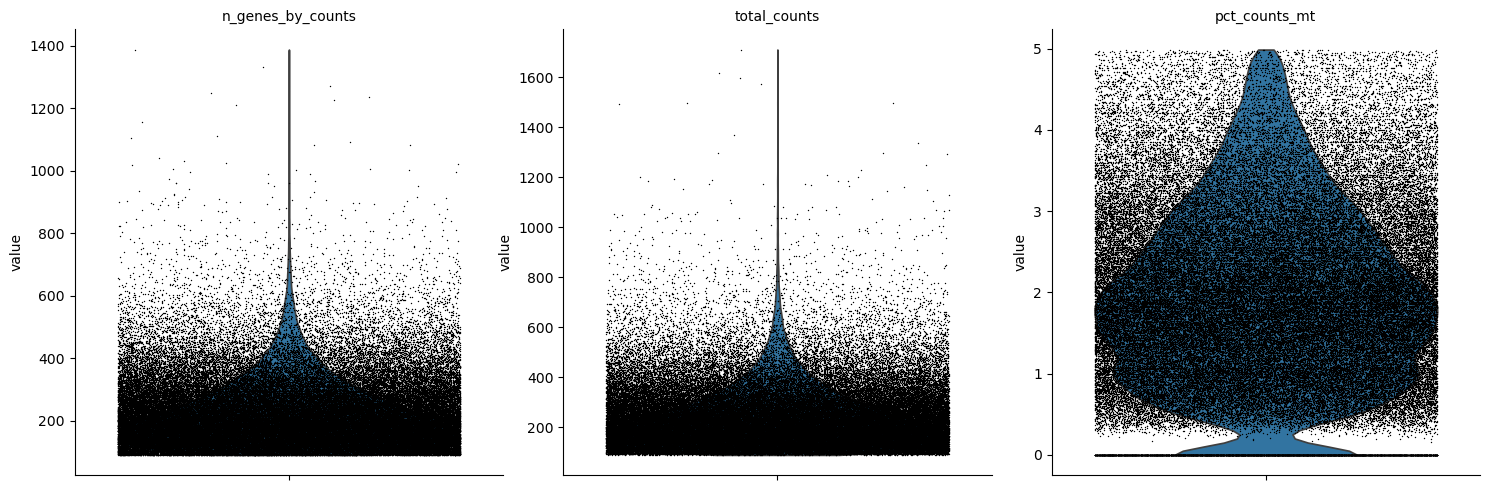

In [27]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

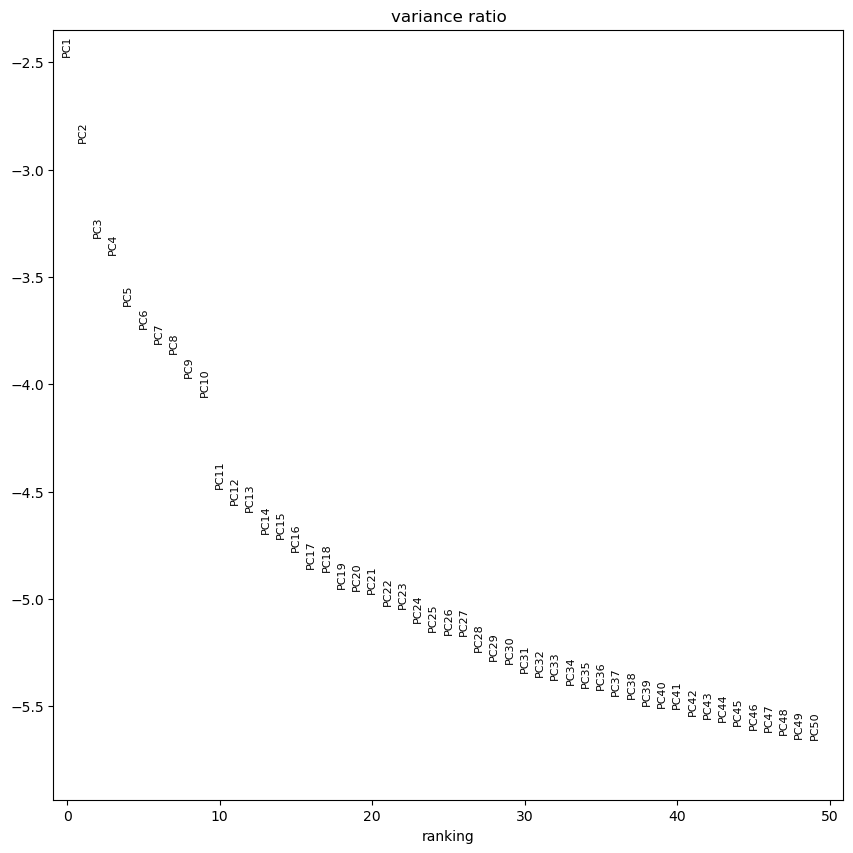

In [28]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

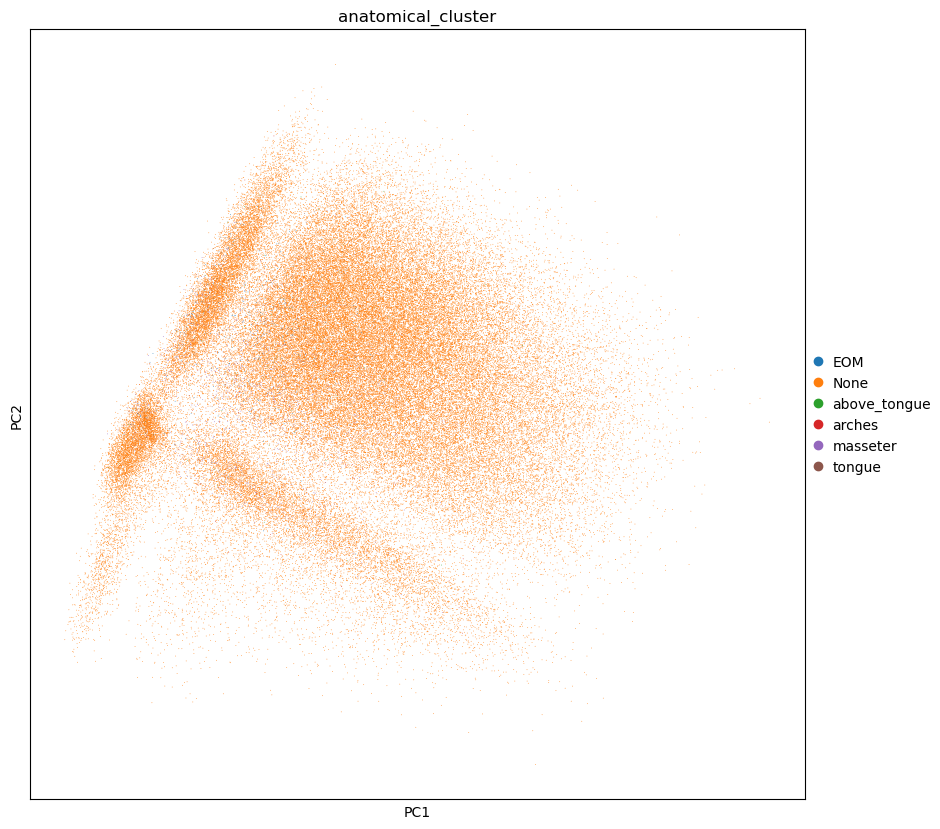

In [41]:
sc.pl.pca(
    adata,
    color=["anatomical_cluster"]
)

In [30]:
sc.pp.neighbors(adata)
sc.tl.umap(adata, n_components=30)

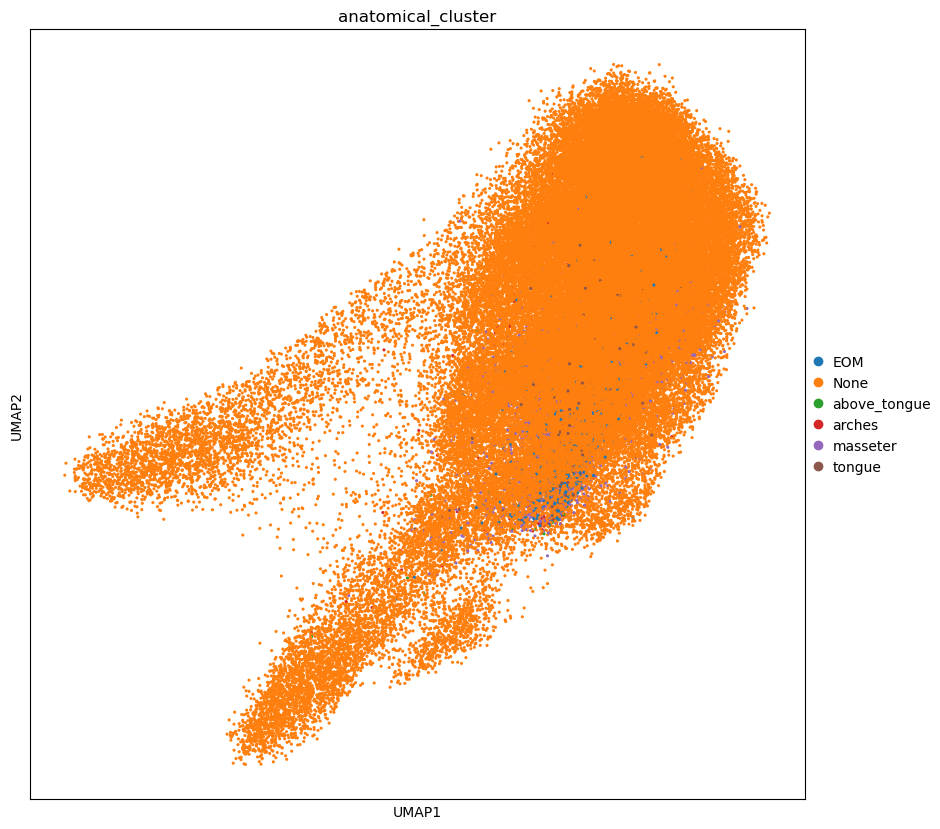

In [33]:
sc.pl.umap(
    adata,
    color="anatomical_cluster",
    size=20
)

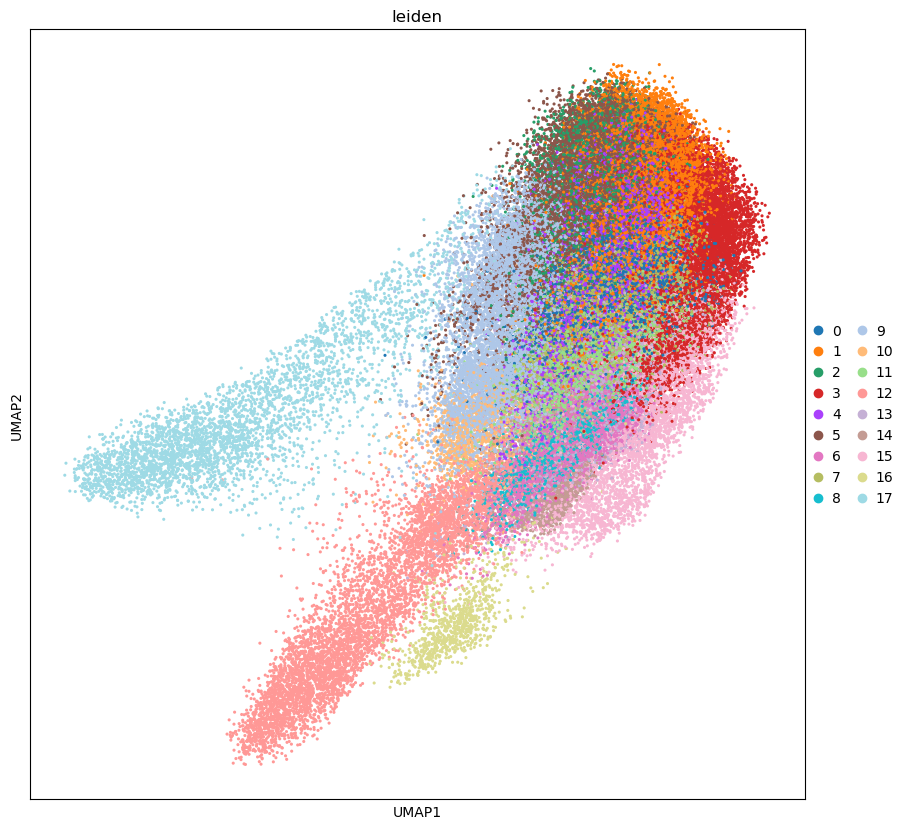

In [34]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
sc.pl.umap(adata, color=["leiden"], size=20)

## Single Cell - Muscle Object

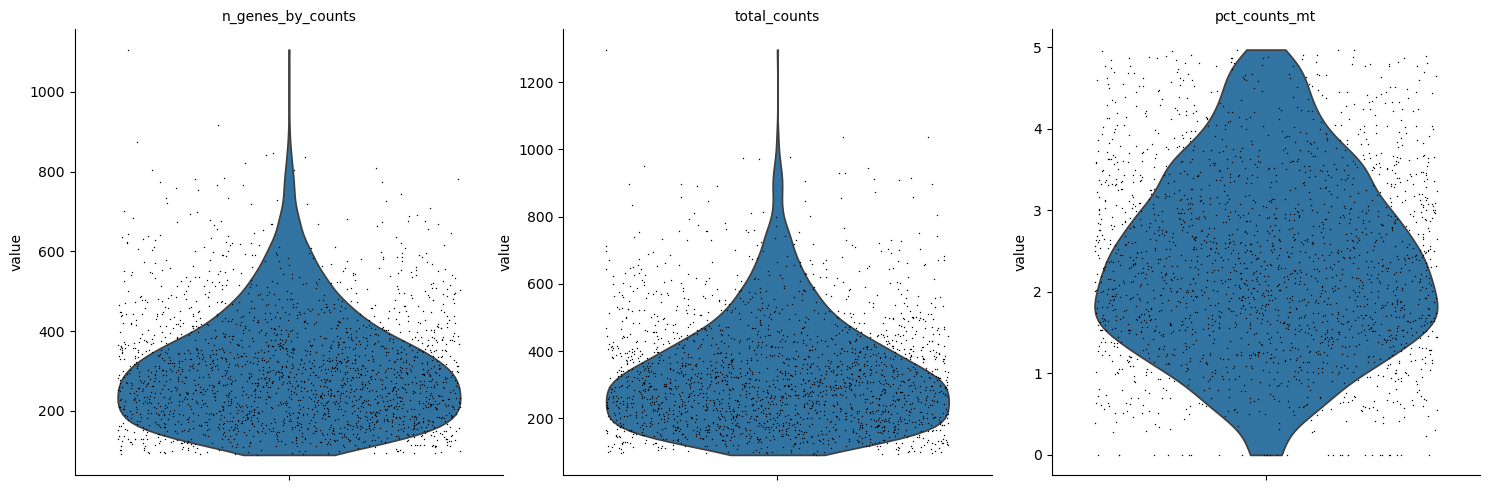

In [10]:
sc.pl.violin(
    adata_muscle,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

/pasteur/appa/homes/npont/miniconda3/envs/st_env/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:383: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


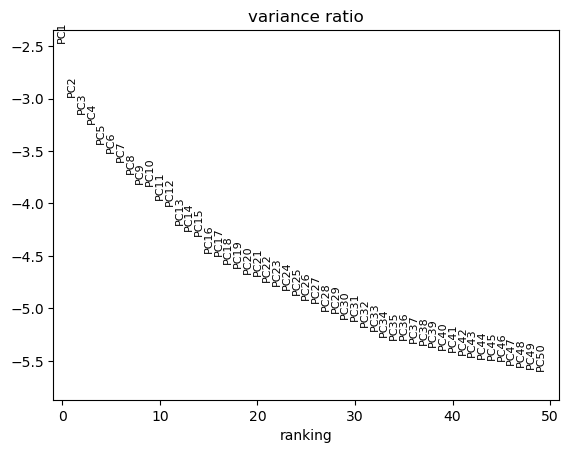

In [6]:
sc.tl.pca(adata_muscle)
sc.pl.pca_variance_ratio(adata_muscle, n_pcs=50, log=True)

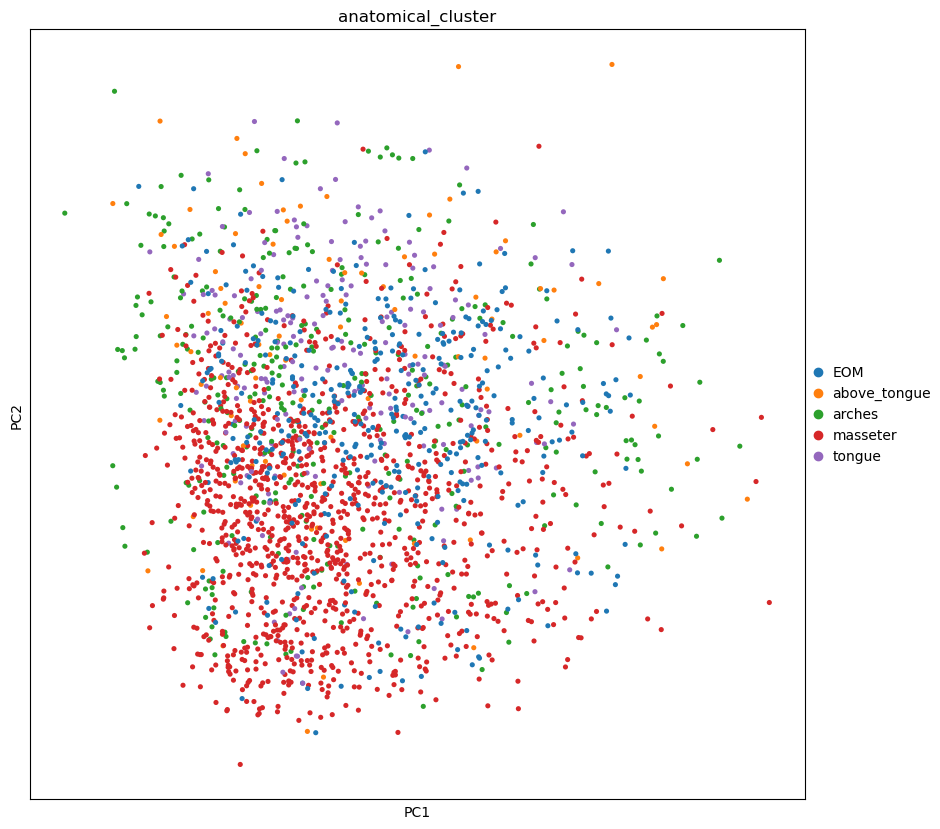

In [40]:
sc.pl.pca(
    adata_muscle,
    color=["anatomical_cluster"]
)

In [21]:
sc.pp.neighbors(adata_muscle)
sc.tl.umap(adata_muscle, n_components=16)

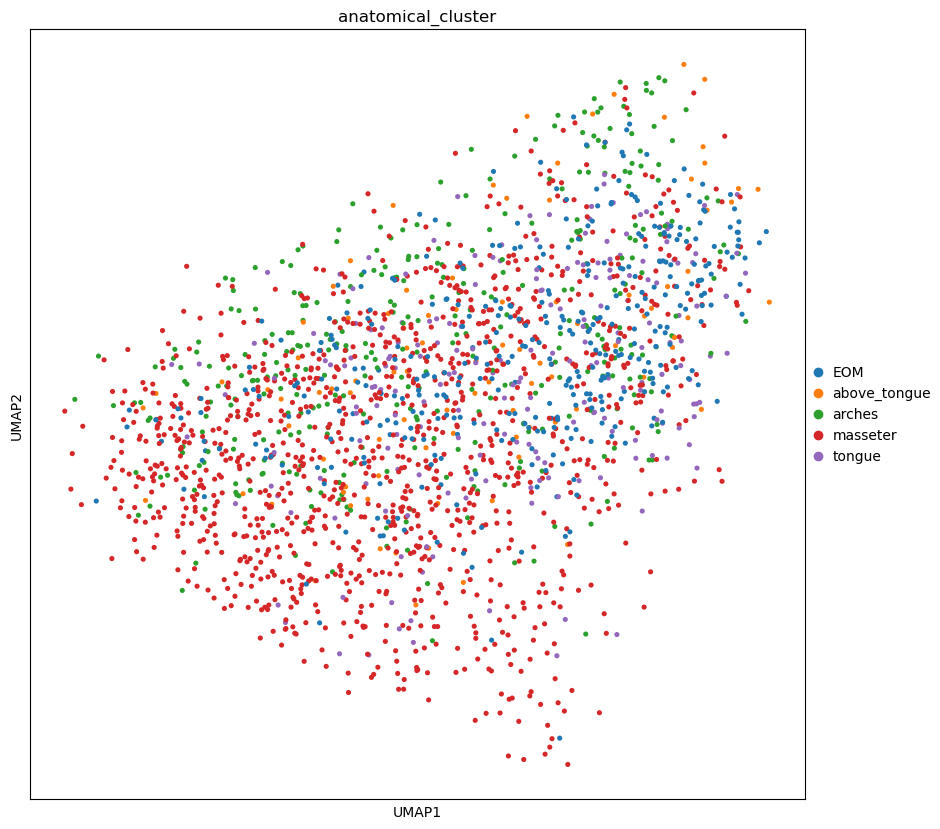

In [26]:
sc.pl.umap(
    adata_muscle,
    color="anatomical_cluster",
)

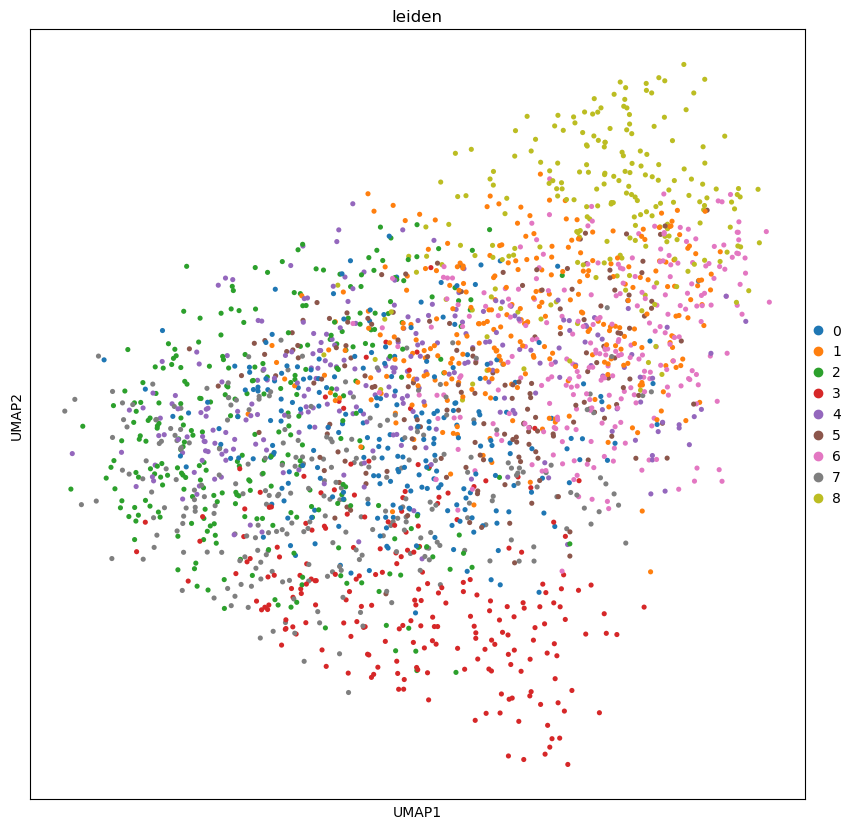

In [25]:
sc.tl.leiden(adata_muscle, flavor="igraph", n_iterations=2)
sc.pl.umap(adata_muscle, color=["leiden"])

## Pseudobulk Level

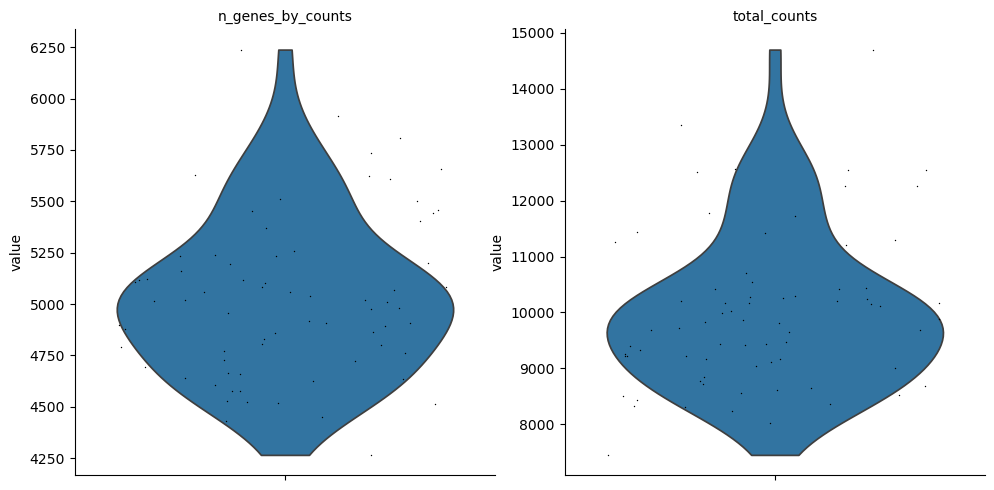

In [36]:
sc.pl.violin(
    pdata_muscle,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

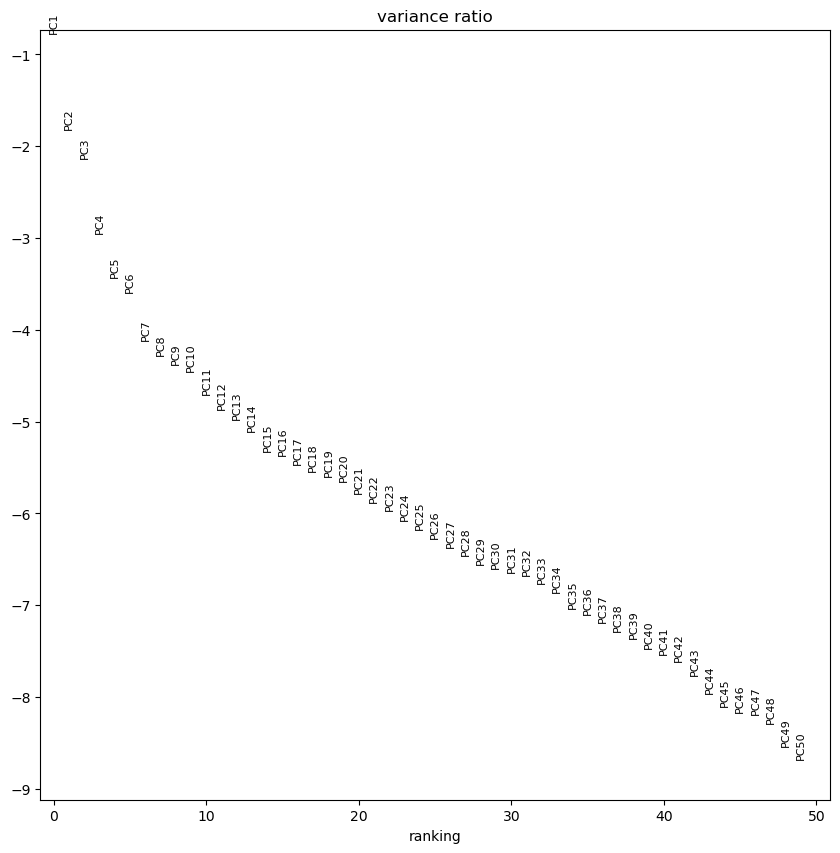

In [37]:
sc.tl.pca(pdata_muscle)
sc.pl.pca_variance_ratio(pdata_muscle, n_pcs=50, log=True)

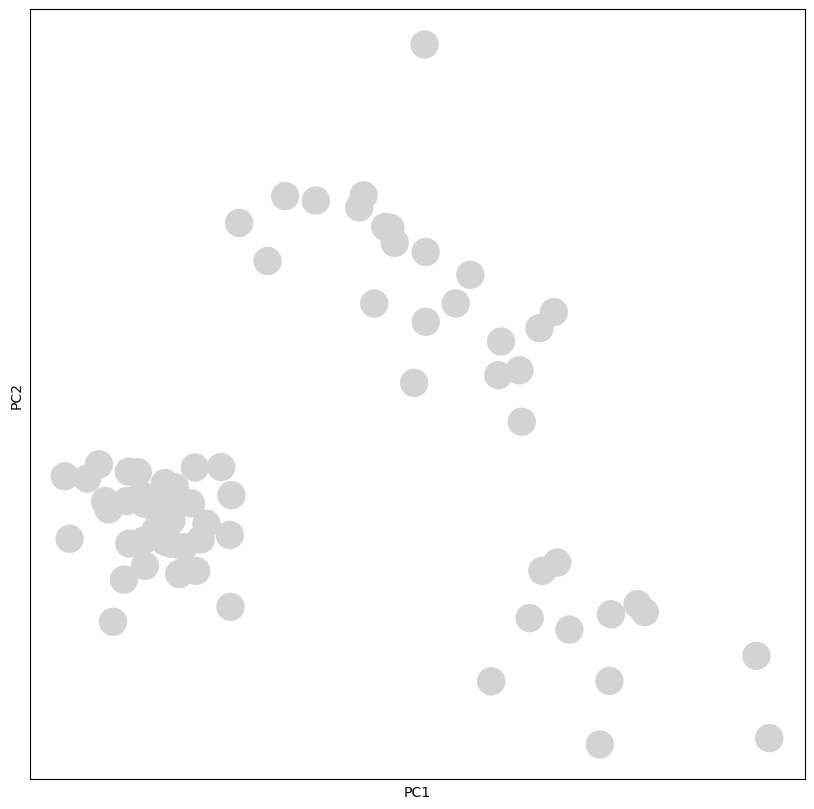

In [38]:
sc.pl.pca(
    pdata_muscle,
    color="anatomical_cluster"
)

In [42]:
sc.pp.neighbors(pdata_muscle)
sc.tl.umap(pdata_muscle, n_components=16)

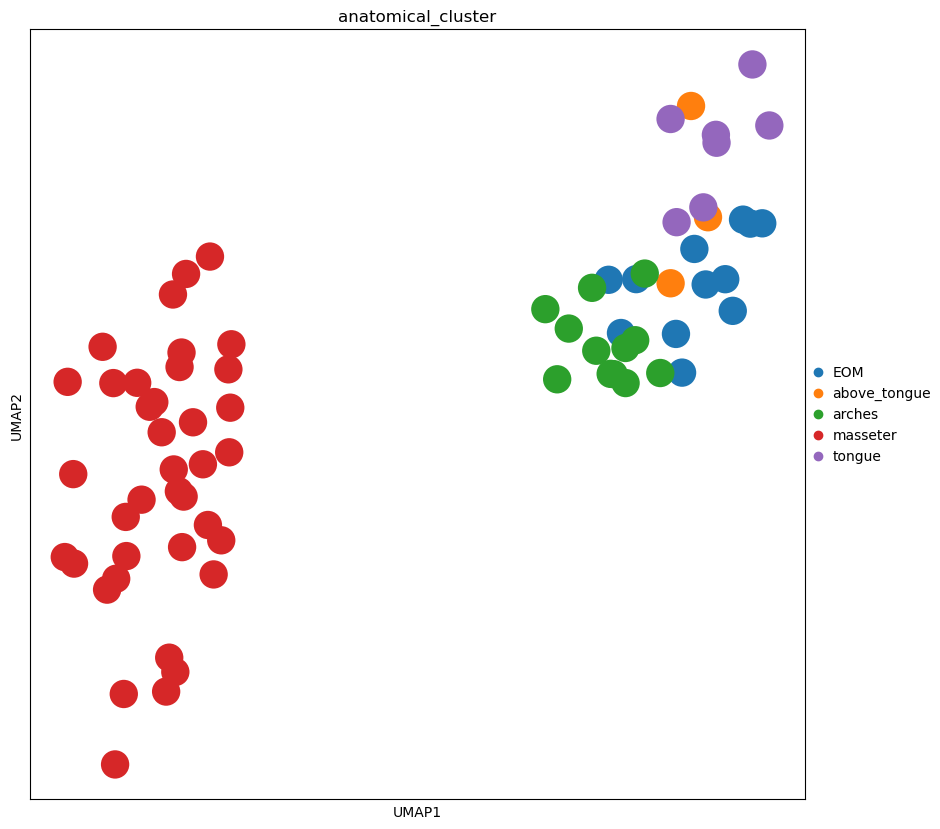

In [43]:
sc.pl.umap(
    pdata_muscle,
    color="anatomical_cluster",
)

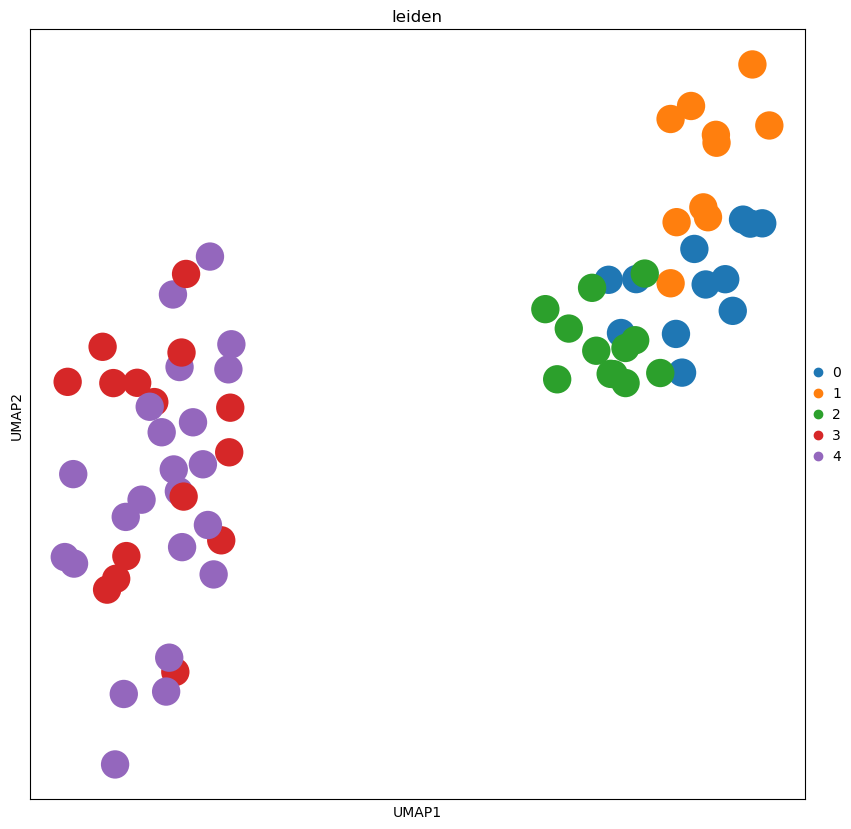

In [44]:
sc.tl.leiden(pdata_muscle, flavor="igraph", n_iterations=2)
sc.pl.umap(pdata_muscle, color=["leiden"])